# Knowledge progression under a random policy

Goal: figure out whether technicians actually *acquire* knowledge during
an episode — and whether different technicians end up specialising in
different patches of the embedding space — when the agent is doing
nothing smarter than picking a random action.  If knowledge plateaus
fast under a random policy, then the `repair_time_delta_per` saturation
we observe in training is **not** the agent learning; it's just the
underlying `ongoing.KnowledgeGrid` saturating regardless of who got
assigned what.

Approach:

1. Build a deliberately **rich** factory with many unique machines.
2. Step the env for a few thousand random decisions.
3. Snapshot every technician's `KnowledgeGrid` at regular intervals.
4. Render the snapshots as a **film** (interactive HTML5 player with
   scrubber + play/pause), and alongside it the scalar evolution.

In [1]:
import sys, pathlib
# Make project src/ importable when the notebook is opened from notebooks/
_here = pathlib.Path.cwd()
for cand in (_here, _here.parent / "src", _here / "src", _here.parent / _here.name):
    if (cand / "kata").exists():
        sys.path.insert(0, str(cand))
        break

import os
os.environ.setdefault("KATA_CONF_PATH", "/dev/null/__no_file__")

import json
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from ongoing import KnowledgeGrid
from kata.core.config import KATAConfig, MachineConfig, ProductConfig, TechnicianConfig
from kata.scenario import ScenarioBuilder
from kata.env import KataEnv
from kata.EntityFactories import create_machine_config, create_technician_config

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = False

## Render helpers for `KnowledgeGrid`

The package doesn't ship a render method, but the grid is just a
2-D experience matrix internally — recover the *knowledge* value at
any (i, j) via ``coords_to_embedding`` + ``get_knowledge``.  We expose
both views: raw *experiences* and the *knowledge* surface
(`= experiences^b`, `b = -log(learning_rate)/log(2)`) which the
simulator actually consumes.

In [2]:
def grid_to_arrays(grid: KnowledgeGrid):
    """Return (experiences_2d, knowledge_2d) numpy arrays."""
    shape = grid._shape
    experiences = np.zeros(shape, dtype=np.float64)
    knowledge = np.zeros(shape, dtype=np.float64)
    for i in range(shape[0]):
        for j in range(shape[1]):
            emb = grid.coords_to_embedding((i, j))
            knowledge[i, j] = grid.get_knowledge(emb)
            experiences[i, j] = grid.get_num_experiences(emb)
    return experiences, knowledge


def animate_grids(snapshots, *, value_key="knowledge", interval_ms=180):
    """Return an HTML5-player animation of per-tech grid evolution.

    One subplot per technician; the player has play/pause and a
    scrubber so you can step through each snapshot.
    """
    tech_labels = list(snapshots[0]["per_tech"].keys())
    n = len(tech_labels)
    # Global vmax so colours are comparable across frames + techs
    idx = 1 if value_key == "knowledge" else 0
    vmax = max(
        float(snap["per_tech"][label][idx].max())
        for snap in snapshots
        for label in tech_labels
    )
    vmax = max(vmax, 1e-3)

    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.2), squeeze=False)
    axes = axes[0]
    ims = []
    for ax, label in zip(axes, tech_labels):
        first = snapshots[0]["per_tech"][label][idx]
        im = ax.imshow(first, cmap="viridis", vmin=0.0, vmax=vmax, animated=True, aspect="equal")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(label, fontsize=10)
        ims.append(im)
    suptitle = fig.suptitle("", fontsize=11)
    fig.colorbar(ims[0], ax=axes.tolist(), shrink=0.85, label=value_key)

    def update(frame_idx):
        snap = snapshots[frame_idx]
        for im, label in zip(ims, tech_labels):
            im.set_data(snap["per_tech"][label][idx])
        suptitle.set_text(f"{value_key} @ step {snap['step']} ({frame_idx + 1}/{len(snapshots)})")
        return list(ims) + [suptitle]

    anim = animation.FuncAnimation(
        fig, update, frames=len(snapshots), interval=interval_ms, blit=False,
    )
    plt.close(fig)  # don't double-render the static frame underneath
    return HTML(anim.to_jshtml())

## Build a deliberately rich factory

To make the heatmap evolution visually interesting we instantiate
**many unique machines** spanning every breakdown-active template.
This gives a wider variety of ticket (machine, component) embeddings
than the default 15-machine pipeline.

In [3]:
SEED = 0
N_STEPS = 2000     # how many random actions to take
SNAPSHOT_EVERY = 50  # snapshot the grids every N steps -> ~40 frames

# Build a custom KATAConfig in-notebook so we control every machine
# (vs. loading one of the run_configs, which might be smaller).
def _machines_dict(spec: list[tuple[str, int]]) -> dict[str, MachineConfig]:
    out: dict[str, MachineConfig] = {}
    for template, count in spec:
        for i in range(count):
            key = f"{template}_{i:02d}"
            out[key] = create_machine_config(template)
    return out


# 30 unique machine instances across 5 templates / 5 machine_types
machines = _machines_dict([
    ("cnc_weibull",      6),  # -> CNC
    ("welder",           6),  # -> Welder
    ("conveyor",         6),  # -> Conveyor
    ("assembly_mixed",   3),  # -> Assembly
    ("assembly_robot",   3),  # -> Assembly
    ("inspection",       6),  # -> Inspection
])
print(f"Machine count:    {len(machines)}")
print(f"Unique types:     {sorted({m.machine_type for m in machines.values()})}")

# 4 uniquely-named technicians
technicians = {
    f"{tpl}_1": create_technician_config(tpl, name=f"{tpl}_1")
    for tpl in ("expert", "senior", "generalist", "junior")
}

products = {
    "widget": ProductConfig(
        product_type="widget",
        route=["Conveyor", "CNC", "Welder", "Assembly", "Inspection"],
    )
}

env_cfg = KATAConfig(
    technicians=technicians,
    machines=machines,
    products=products,
)
env_cfg.gym.observation_representation = "structured"
env_cfg.gym.use_mca_encoder = False
env_cfg.gym.max_episode_steps = N_STEPS + 10
env_cfg.gym.max_sim_time = 10_000_000.0  # effectively unbounded

env = KataEnv(scenario_factory=lambda: ScenarioBuilder(env_cfg).build(), config=env_cfg.gym)
env.reset(seed=SEED)
techs = env.dispatcher.techs
tech_labels = [t.name for t in techs]
print(f"\nBuilt env with {len(techs)} techs: {tech_labels}")
print(f"Each KnowledgeGrid shape: {techs[0].knowledge_grid._shape}")

Machine count:    30
Unique types:     ['Assembly', 'CNC', 'Conveyor', 'Inspection', 'Welder']

Built env with 4 techs: ['expert_1', 'senior_1', 'generalist_1', 'junior_1']
Each KnowledgeGrid shape: (10, 10)


## Run a long random-action rollout, capturing many snapshots

In [4]:
random.seed(SEED); np.random.seed(SEED)

def snapshot(step: int):
    return {
        "step": step,
        "per_tech": {t.name: grid_to_arrays(t.knowledge_grid) for t in techs},
    }

snapshots = [snapshot(0)]
done = False
n = 0
while not done and n < N_STEPS:
    a = random.randrange(env.action_space.n)
    obs, r, term, trunc, info = env.step(a)
    n += 1
    done = term or trunc
    if n % SNAPSHOT_EVERY == 0:
        snapshots.append(snapshot(n))

if snapshots[-1]["step"] != n:
    snapshots.append(snapshot(n))

print(f"Episode ended at step {n}.")
print(f"Captured {len(snapshots)} snapshots, spaced every {SNAPSHOT_EVERY} steps")

Episode ended at step 2000.
Captured 41 snapshots, spaced every 50 steps


## Film — knowledge surface evolving over time

Each technician occupies one subplot.  Use the **scrubber / play
button** below the figure to scroll through the rollout.  Colour
scale is shared across techs and across frames so brightness is
directly comparable.

Look for:

* **Cells lighting up at all** — is knowledge actually accumulating?
* **Different bright cells per tech** — are techs specialising or
  converging to the same patch?
* **Saturation timing** — does the brightest cell plateau within the
  first ~10 frames?

In [5]:
animate_grids(snapshots, value_key="knowledge")

## Film — raw experience counts

Same view, but on `get_num_experiences` instead of `get_knowledge`.
Useful to confirm that ticket events are landing where you expect
(experiences are unbounded; knowledge is bounded by `experiences^b`).

In [6]:
animate_grids(snapshots, value_key="experiences")

## Scalar evolution — how fast does each tech accumulate?

Three curves per tech:

* `peak knowledge` — `grid.get_max_knowledge()` (drives the multiplier).
* `peak experiences` — `grid.get_max_experiences()` (raw count).
* `# cells > 0` — how spread-out the knowledge surface is.

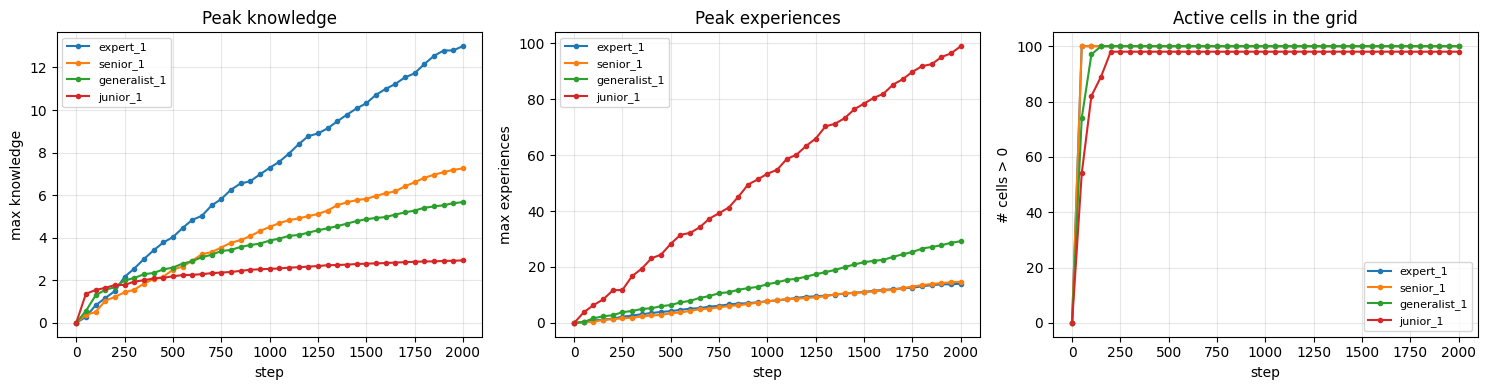

In [7]:
xs = [s["step"] for s in snapshots]
peak_k = {label: [] for label in tech_labels}
peak_e = {label: [] for label in tech_labels}
spread = {label: [] for label in tech_labels}

for snap in snapshots:
    for label in tech_labels:
        exps, kn = snap["per_tech"][label]
        peak_k[label].append(float(kn.max()))
        peak_e[label].append(float(exps.max()))
        spread[label].append(int((kn > 1e-6).sum()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for label in tech_labels:
    axes[0].plot(xs, peak_k[label], marker="o", ms=3, label=label)
    axes[1].plot(xs, peak_e[label], marker="o", ms=3, label=label)
    axes[2].plot(xs, spread[label], marker="o", ms=3, label=label)
axes[0].set(xlabel="step", ylabel="max knowledge", title="Peak knowledge")
axes[1].set(xlabel="step", ylabel="max experiences", title="Peak experiences")
axes[2].set(xlabel="step", ylabel="# cells > 0", title="Active cells in the grid")
for ax in axes:
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Implied repair-time multiplier at the peak cell

Translate peak knowledge into the actual multiplier the simulator
uses (`min_floor + (1-min_floor)*exp(-α*k)`) with the same defaults
as `sim.repair`.  This tells you, given the **peak** knowledge per
tech, what *floor* of repair-time-saving each tech has achieved.

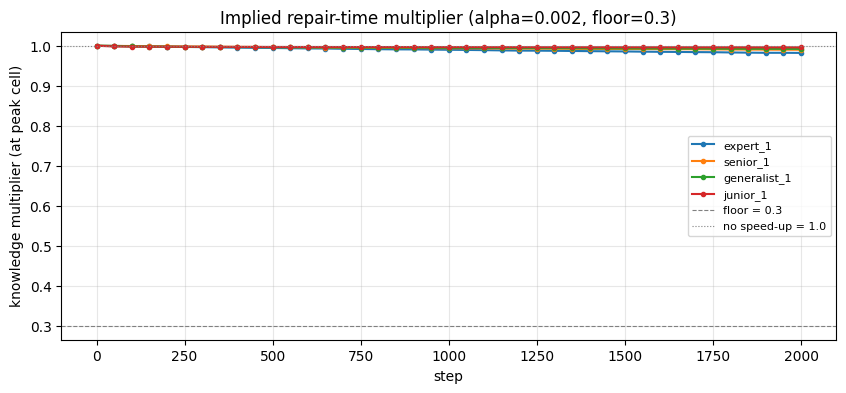

In [8]:
MIN_FLOOR = float(env_cfg.sim.repair.min_repair_fraction)
ALPHA = float(env_cfg.sim.repair.knowledge_sensitivity)

def multiplier(k):
    return MIN_FLOOR + (1.0 - MIN_FLOOR) * np.exp(-ALPHA * k)

fig, ax = plt.subplots()
for label in tech_labels:
    mults = [multiplier(v) for v in peak_k[label]]
    ax.plot(xs, mults, marker="o", ms=3, label=label)
ax.axhline(MIN_FLOOR, ls="--", color="grey", lw=0.8, label=f"floor = {MIN_FLOOR}")
ax.axhline(1.0, ls=":", color="grey", lw=0.8, label="no speed-up = 1.0")
ax.set(xlabel="step", ylabel="knowledge multiplier (at peak cell)",
       title=f"Implied repair-time multiplier (alpha={ALPHA}, floor={MIN_FLOOR})")
ax.grid(True, alpha=0.3); ax.legend(fontsize=8)
plt.show()

## Diagnostic: did all techs see the same ticket distribution?

If every tech ended up handling the same mix of tickets under random
scheduling, the heatmaps will look near-identical regardless of
"learning".  Print the per-tech ticket breakdown.

In [9]:
from collections import Counter, defaultdict

env.reset(seed=SEED)
random.seed(SEED)
per_tech_tickets: dict[str, Counter] = defaultdict(Counter)

done = False
n = 0
while not done and n < N_STEPS:
    ticket = env.current_request
    a = random.randrange(env.action_space.n)
    tech_label = techs[a].name
    if ticket is not None:
        mt = getattr(getattr(ticket, "machine", None), "mtype", "?")
        ci = ticket.get_failed_component_info() if hasattr(ticket, "get_failed_component_info") else None
        ct = (ci or {}).get("component_type", "none")
        per_tech_tickets[tech_label][(mt, ct)] += 1
    obs, _, term, trunc, _ = env.step(a)
    n += 1
    done = term or trunc

for label in tech_labels:
    print(f"\n{label}: {sum(per_tech_tickets[label].values())} tickets")
    for (mt, ct), n_tickets in per_tech_tickets[label].most_common(8):
        print(f"  {mt:>12s} / {ct:<14s}  {n_tickets}")


expert_1: 503 tickets
      Conveyor / mechanical      156
           CNC / spindle         70
    Inspection / sensor          67
           CNC / pump            45
      Assembly / motor           37
        Welder / torch           31
        Welder / electronics     24
      Assembly / end_effector    22

senior_1: 538 tickets
      Conveyor / mechanical      168
    Inspection / sensor          63
           CNC / spindle         62
           CNC / pump            48
      Assembly / motor           40
      Assembly / end_effector    34
        Welder / pump            31
        Welder / torch           29

generalist_1: 474 tickets
      Conveyor / mechanical      126
    Inspection / sensor          71
           CNC / spindle         53
      Assembly / motor           38
           CNC / pump            37
        Welder / torch           37
        Welder / electronics     28
        Welder / pump            25

junior_1: 485 tickets
      Conveyor / mechanical      139


## Takeaways

* If the **peak-knowledge curves** saturate within the first ~10
  frames of the film, then `repair_time_delta_per` hitting its ceiling
  during training is *not* the agent learning — it's the grid
  saturating mechanically regardless of policy.
* If the **heatmap film** shows every tech's grid lighting up the
  *same* cells, the random policy is distributing work so uniformly
  that techs aren't differentiated — meaning the *agent* has no
  specialisation room to learn beyond what random play already gives.
* If only one or two cells are ever bright, the encoder is collapsing
  many distinct repair types onto the same grid cell (a known
  pre-existing issue with the default ``HashEncoder``).